# 0 · Install Dependencies

In [16]:
!pip install transformers datasets torch scipy scikit-learn tqdm -q

# 1 · Imports & Config

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader
# Explicit imports — replaces `from transformers import *` in original model.py
from transformers import (
    BertTokenizer,
    RobertaTokenizer,
    BertModel,
    RobertaModel,
    BertConfig,
    RobertaConfig,
    BertPreTrainedModel,
    get_linear_schedule_with_warmup,
)
from scipy.stats import pearsonr
from sklearn.metrics import classification_report, jaccard_score
from tqdm.auto import tqdm
import pandas as pd

# PATHS
MODEL_DIR_PATH = "./models/"
DATA_DIR_PATH = "./data/"
OUTPUT_DIR_PATH = "./output/"

# ── Config ────────────────────────────────────────────────────────────────────
# src/main_ori.py → SingleDatasetTrainer._set_model_args()
MODEL_ARCH   = "bert"              # "bert" | "roberta"
MODEL_NAME   = "bert-base-uncased" # swap to "bert-large-cased-whole-word-masking" to match paper
MAX_LEN      = 128
BATCH_SIZE   = 16
EPOCHS       = 3
LR           = 2e-5
LR_UNFREEZE  = 5e-6               # used in two-phase training (Stage 2)
WARMUP_RATIO = 0.1
CLIP_GRAD    = 1.0
CONTEXT_WINDOW = 3                   # prior turns prepended as BERT Segment A (context-window inference)
UPDATE_FREQ  = 1                  # gradient accumulation steps

# Task: "vad-from-categories" | "category-classification" | "vad-regression"
TASK         = "vad-from-categories"
# Dataset label type: "multi" (multi-label) | "single" (single-label)
LABEL_TYPE   = "multi"

Apple Silicon MPS


In [40]:
# src/models/trainer.py → Trainer.set_device()
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Apple Silicon MPS")
else:
    DEVICE = torch.device("cpu")
    print("CPU")

Apple Silicon MPS


# Stage 2 — Supervised VAD Regression

In [ ]:
# src/data/__init__.py → EmotionDataset.__getitem__()
# Tokenizer selection mirrors main_ori.py → SingleDatasetTrainer.load_tokenizer()

if MODEL_ARCH == "bert":
    tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
else:  # roberta
    tokenizer = RobertaTokenizer.from_pretrained(MODEL_NAME)


class EmotionDataset(Dataset):
    """
    Wraps texts + labels for DataLoader consumption.
    For LABEL_TYPE='multi'  labels are float tensors (BCEWithLogitsLoss compatible).
    For LABEL_TYPE='single' labels are long tensors  (CrossEntropyLoss compatible).
    For vad-regression      labels are float tensors shaped (N, 3).
    """

    def __init__(self, texts, labels):
        self.texts  = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        raw_label = self.labels[idx]
        if LABEL_TYPE == "single":
            label_tensor = torch.tensor(raw_label, dtype=torch.long)
        else:  # multi or regression
            label_tensor = torch.tensor(raw_label, dtype=torch.float)

        return (
            enc["input_ids"].squeeze(0),       # (MAX_LEN,)
            enc["attention_mask"].squeeze(0),  # (MAX_LEN,)
            label_tensor,                      # (N_LABELS,) or scalar
        )


## 11 · EmoBank Data

In [28]:
# src/data/loader.py → EmobankLoader.load_data() / _preprocessing_text()
# Raw V/A/D labels on 1-5 scale (no normalisation — matches CLAUDE.md).
# Update EMOBANK_PATH for your machine.

EMOBANK_PATH = DATA_DIR_PATH + "emobank.csv"   # ← update if needed

eb_df    = pd.read_csv(EMOBANK_PATH)
eb_train = eb_df[eb_df["split"] == "train"]
eb_dev   = eb_df[eb_df["split"] == "dev"]
eb_test  = eb_df[eb_df["split"] == "test"]

def _clean_eb(text: str) -> str:
    # src/data/loader.py → EmobankLoader._preprocessing_text() lines 126-137
    t = str(text).strip('"').strip("'").strip()
    t = re.sub(r"([{}])".format(re.escape(string.punctuation)), r" \1 ", t)
    t = re.sub(r"\s{2,}", " ", t)
    return t.strip()

def _df_to_lists(df):
    texts  = [_clean_eb(t) for t in df["text"].tolist()]
    labels = [[row["V"], row["A"], row["D"]] for _, row in df.iterrows()]
    return texts, labels

eb_train_texts, eb_train_labels = _df_to_lists(eb_train)
eb_dev_texts,   eb_dev_labels   = _df_to_lists(eb_dev)
eb_test_texts,  eb_test_labels  = _df_to_lists(eb_test)

print(f"EmoBank — Train: {len(eb_train_texts):,}  "
      f"Dev: {len(eb_dev_texts):,}  Test: {len(eb_test_texts):,}")

# Reuse EmotionDataset from § 4 (labels become (3,) float tensors)
eb_train_ldr = DataLoader(
    EmotionDataset(eb_train_texts, eb_train_labels),
    batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
eb_dev_ldr   = DataLoader(
    EmotionDataset(eb_dev_texts,   eb_dev_labels),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
eb_test_ldr  = DataLoader(
    EmotionDataset(eb_test_texts,  eb_test_labels),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

EmoBank — Train: 8,062  Dev: 1,000  Test: 1,000


## 11 · AnnoMI Data (with VAD annotated from demo_1)

In [36]:
# ── AnnoMI splits produced by demo_1.ipynb (annomi-split cell) ──────────────
# Each CSV has columns:
#   transcript_id | utterance_id | interlocutor | utterance_text
#   main_therapist_behaviour | client_talk_type | V | A | D
# V / A / D are model_s2 predictions on EmoBank 1-5 scale (used as labels).

ANNOMI_TRAIN_PATH = OUTPUT_DIR_PATH + "annomi_train.csv"
ANNOMI_DEV_PATH   = OUTPUT_DIR_PATH + "annomi_dev.csv"
ANNOMI_TEST_PATH  = OUTPUT_DIR_PATH + "annomi_test.csv"

# ── Load ──────────────────────────────────────────────────────────────────────
am_train_df = pd.read_csv(ANNOMI_TRAIN_PATH)
am_dev_df   = pd.read_csv(ANNOMI_DEV_PATH)
am_test_df  = pd.read_csv(ANNOMI_TEST_PATH)

# ── Clean: keep the six structural columns + VAD labels ──────────────────────
_KEEP = [
    "transcript_id",
    "utterance_id",
    "interlocutor",             # "therapist" | "client"
    "utterance_text",
    "main_therapist_behaviour", # question / reflection / therapist_input / other
    "client_talk_type",         # neutral / change / sustain
    "V", "A", "D",              # VAD labels (EmoBank 1-5 scale)
]

am_train_df = am_train_df[_KEEP].reset_index(drop=True)
am_dev_df   = am_dev_df[_KEEP].reset_index(drop=True)
am_test_df  = am_test_df[_KEEP].reset_index(drop=True)

print(f"Train : {len(am_train_df):>5,} utterances  "
      f"{am_train_df['transcript_id'].nunique():>3} sessions")
print(f"Dev   : {len(am_dev_df):>5,} utterances  "
      f"{am_dev_df['transcript_id'].nunique():>3} sessions")
print(f"Test  : {len(am_test_df):>5,} utterances  "
      f"{am_test_df['transcript_id'].nunique():>3} sessions")
display(am_train_df.head(4))
# DataLoaders are built in § 12 (after encode_with_context is defined)


Train : 7,482 utterances  106 sessions
Dev   : 1,656 utterances   13 sessions
Test  :   561 utterances   14 sessions


,transcript_id,utterance_id,interlocutor,utterance_text,main_therapist_behaviour,client_talk_type,V,A,D
0,0,0,therapist,Thanks for filling it out. We give this form t...,question,NaN,3.366,3.102,3.055
1,0,1,client,Sure.,NaN,neutral,3.106,2.884,3.117
2,0,2,therapist,"So, let's see. It looks that you put-- You dri...",therapist_input,NaN,2.974,2.939,3.088
3,0,3,client,Mm-hmm.,NaN,neutral,3.071,2.865,2.992


## 12 · BertForVADRegression

In [37]:
# BERT [CLS] → Dropout(0.1) → Linear(768, 3)
# src/models/model.py → PretrainedLMModel (task='vad-regression', load_checkpoint=False)

class BertForVADRegression(nn.Module):
    """
    Stage 2 regression head.
    Predicts continuous [V, A, D] on EmoBank's 1-5 scale.
    Encoder warm-started from Stage 1 checkpoint (best_model.pt).
    """
    def __init__(self):
        super().__init__()
        self.bert    = BertModel.from_pretrained(MODEL_NAME)
        self.dropout = nn.Dropout(0.1)
        self.head    = nn.Linear(self.bert.config.hidden_size, 3)

    def forward(self, input_ids, attention_mask=None, token_type_ids=None):
        # src/models/model.py → PretrainedLMModel.forward() lines 109-129
        _, pooled = self.bert(
            input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            return_dict=False,
        )
        return self.head(self.dropout(pooled))   # (B, 3)


# ── Load Stage 1 encoder from best_model.pt ───────────────────────────────────
# Stage 1 stores BERT as 'pre_trained_lm.*'; remap to 'bert.*' for Stage 2.
# Drop 'head.*' — Stage 1 head shape (768→N_LABELS*3) is incompatible.
# src/models/trainer.py → load_model_from_ckeckpoint() lines 290-316

model_s2 = BertForVADRegression().to(DEVICE)
ckpt_s1  = torch.load(MODEL_DIR_PATH + "best_model.pt", map_location=DEVICE)

remap = {}
for k, v in ckpt_s1.items():
    if k.startswith("pre_trained_lm."):
        remap["bert." + k[len("pre_trained_lm."):]] = v
    elif k.startswith("dropout."):
        remap[k] = v
    # head.* intentionally skipped

missing, unexpected = model_s2.load_state_dict(remap, strict=False)
print(f"Encoder keys loaded : {len(remap)}")
print(f"Missing (new head)  : {missing}")    # expected: ['head.weight', 'head.bias']
print(f"Unexpected          : {unexpected}") # expected: []

# ── Context-window encoder ────────────────────────────────────────────────────
# Encodes a transcript turn with up to CONTEXT_WINDOW prior turns as Segment A.
# EmoBank fine-tuning uses single-sentence inputs (no conversational structure);
# context windowing is applied only at inference time on the therapy transcript.

def encode_with_context(turns: list, idx: int, tok, max_len: int = MAX_LEN):
    """
    Build a BERT sentence-pair input for turn at position `idx`.

    Segment A (token_type_id=0): up to CONTEXT_WINDOW prior turns, each
        formatted as "speaker: text", joined by spaces.
    Segment B (token_type_id=1): the current turn "speaker: text".

    BERT's sentence-pair truncation drops tokens from the *longest* side
    first, so long context is safely clipped while current text is preserved.
    """
    current   = turns[idx]
    ctx_turns = turns[max(0, idx - CONTEXT_WINDOW): idx]

    ctx_str = " ".join(f"{t['speaker']}: {t['text']}" for t in ctx_turns)
    cur_str = f"{current['speaker']}: {current['text']}"

    if ctx_str:
        enc = tok(
            ctx_str, cur_str,
            max_length=max_len,
            padding="max_length",
            truncation=True,        # truncates the longest sequence first
            return_tensors="pt",
        )
    else:
        enc = tok(
            cur_str,
            max_length=max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
    return enc


# ── AnnoMIContextDataset ──────────────────────────────────────────────────────
# Context-aware Dataset for AnnoMI training.
# Each item encodes a BERT sentence pair:
#   Segment A (token_type_id=0): up to CONTEXT_WINDOW prior turns
#                                formatted as "interlocutor: text"
#   Segment B (token_type_id=1): the current turn
# Utterances are grouped by transcript_id so context stays within a session.

class AnnoMIContextDataset(Dataset):
    def __init__(self, df: pd.DataFrame, max_len: int = MAX_LEN):
        self.max_len = max_len
        self.samples: list = []

        for _, grp in df.groupby("transcript_id"):
            grp = grp.sort_values("utterance_id").reset_index(drop=True)
            # Reuse encode_with_context's expected dict format
            turns = [
                {"speaker": row["interlocutor"], "text": row["utterance_text"]}
                for _, row in grp.iterrows()
            ]
            labels = grp[["V", "A", "D"]].values.tolist()
            for i in range(len(turns)):
                self.samples.append((turns, i, labels[i]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        turns, i, label = self.samples[idx]
        enc = encode_with_context(turns, i, tokenizer, self.max_len)
        # token_type_ids present for sentence-pair inputs, zeros for single-sentence
        tti = enc.get("token_type_ids",
                      torch.zeros(self.max_len, dtype=torch.long))
        return (
            enc["input_ids"].squeeze(0),       # (MAX_LEN,)
            enc["attention_mask"].squeeze(0),  # (MAX_LEN,)
            tti.squeeze(0),                    # (MAX_LEN,)
            torch.tensor(label, dtype=torch.float),  # (3,)
        )


# ── Build DataLoaders ─────────────────────────────────────────────────────────
am_train_ldr = DataLoader(
    AnnoMIContextDataset(am_train_df), batch_size=BATCH_SIZE,
    shuffle=True,  num_workers=0)
am_dev_ldr   = DataLoader(
    AnnoMIContextDataset(am_dev_df),   batch_size=BATCH_SIZE,
    shuffle=False, num_workers=0)
am_test_ldr  = DataLoader(
    AnnoMIContextDataset(am_test_df),  batch_size=BATCH_SIZE,
    shuffle=False, num_workers=0)

print(f"\nAnnoMI context DataLoaders (CONTEXT_WINDOW={CONTEXT_WINDOW}, "
      f"batch_size={BATCH_SIZE}):")
print(f"  am_train_ldr : {len(am_train_ldr)} batches")
print(f"  am_dev_ldr   : {len(am_dev_ldr)} batches")
print(f"  am_test_ldr  : {len(am_test_ldr)} batches")

# ── Sanity-check one batch ────────────────────────────────────────────────────
_ids, _mask, _tti, _lbl = next(iter(am_train_ldr))
print(f"Sample batch — ids:{_ids.shape}  mask:{_mask.shape}  "
      f"tti:{_tti.shape}  labels:{_lbl.shape}")
print(f"token_type_ids unique values in batch: {_tti.unique().tolist()} "
      f"(0=context, 1=current turn)")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoder keys loaded : 199
Missing (new head)  : ['head.weight', 'head.bias']
Unexpected          : []

AnnoMI context DataLoaders (CONTEXT_WINDOW=3, batch_size=16):
  am_train_ldr : 468 batches
  am_dev_ldr   : 104 batches
  am_test_ldr  : 36 batches
Sample batch — ids:torch.Size([16, 128])  mask:torch.Size([16, 128])  tti:torch.Size([16, 128])  labels:torch.Size([16, 3])
token_type_ids unique values in batch: [0, 1] (0=context, 1=current turn)


# 13 · Two-Phase Training

In [41]:
# src/main_ori.py → SingleDatasetTrainer.train() lines 363-376
# Updated for context-aware AnnoMI DataLoaders:
#   batches are (input_ids, attention_mask, token_type_ids, labels)

FREEZE_EPOCHS   = 5   # epochs with encoder frozen
UNFREEZE_EPOCHS = 5   # epochs with all params unfrozen
LR_FREEZE       = 3e-3
# LR_UNFREEZE = 5e-6 already set in § 1 Config

mse_loss = nn.MSELoss()


def _train_epoch_vad(mdl, loader, opt):
    mdl.train()
    total = 0.0
    for batch in tqdm(loader, desc="  train-vad", leave=False):
        ids, mask, tti, labels = [b.to(DEVICE) for b in batch]
        loss = mse_loss(mdl(ids, attention_mask=mask, token_type_ids=tti), labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(mdl.parameters(), CLIP_GRAD)
        opt.step()
        opt.zero_grad()
        total += loss.item()
    return total / len(loader)


@torch.no_grad()
def _eval_vad(mdl, loader):
    """Pearson r per VAD dimension."""
    mdl.eval()
    preds_list, labels_list = [], []
    for batch in tqdm(loader, desc="  eval-vad", leave=False):
        ids, mask, tti, labels = [b.to(DEVICE) for b in batch]
        preds_list.append(mdl(ids, attention_mask=mask, token_type_ids=tti).cpu())
        labels_list.append(labels.cpu())
    P = torch.cat(preds_list).numpy()
    L = torch.cat(labels_list).numpy()
    # src/models/trainer.py → Trainer._compute_vad_eval_metrics() lines 402-405
    return [pearsonr(P[:, i], L[:, i])[0] for i in range(3)]   # [r_V, r_A, r_D]


best_eb_r = float("-inf")

for phase, (n_ep, lr) in enumerate(
        [(FREEZE_EPOCHS, LR_FREEZE), (UNFREEZE_EPOCHS, LR_UNFREEZE)], start=1):

    if phase == 1:
        for p in model_s2.bert.parameters():
            p.requires_grad = False
        trainable = model_s2.head.parameters()
        print("Phase 1: encoder frozen, training head only")
    else:
        for p in model_s2.parameters():
            p.requires_grad = True
        trainable = model_s2.parameters()
        print("Phase 2: all parameters unfrozen")

    opt_s2 = torch.optim.AdamW(trainable, lr=lr)

    for ep in range(1, n_ep + 1):
        tr_loss       = _train_epoch_vad(model_s2, am_train_ldr, opt_s2)
        r_v, r_a, r_d = _eval_vad(model_s2, am_dev_ldr)
        mean_r        = (r_v + r_a + r_d) / 3
        print(f"  Ph{phase} Ep {ep:>2}/{n_ep}  loss={tr_loss:.4f}  "
              f"r_V={r_v:.4f}  r_A={r_a:.4f}  r_D={r_d:.4f}  mean_r={mean_r:.4f}")
        if mean_r > best_eb_r:
            best_eb_r = mean_r
            torch.save(model_s2.state_dict(), MODEL_DIR_PATH + "best_am_context_model.pt")
            print("  Saved " + MODEL_DIR_PATH + "best_am_context_model.pt")

print(f"\nStage 2 complete — best mean Pearson r (dev) = {best_eb_r:.4f}")

# ── Test-set evaluation ────────────────────────────────────────────
model_s2.load_state_dict(torch.load(MODEL_DIR_PATH + "best_am_context_model.pt", map_location=DEVICE))
r_v, r_a, r_d = _eval_vad(model_s2, am_test_ldr)
mean_r_test   = (r_v + r_a + r_d) / 3
print("\n" + "=" * 52)
print("  Stage 2 — AnnoMI Test-Set Evaluation (context-aware)")
print("=" * 52)
print(f"  Valence   (r) = {r_v:+.4f}")
print(f"  Arousal   (r) = {r_a:+.4f}")
print(f"  Dominance (r) = {r_d:+.4f}")
print(f"  Mean Pearson r = {mean_r_test:.4f}")
print("=" * 52)


Phase 1: encoder frozen, training head only


  train-vad:   0%|          | 0/468 [00:00<?, ?it/s]

  eval-vad:   0%|          | 0/104 [00:00<?, ?it/s]

  Ph1 Ep  1/5  loss=0.0552  r_V=0.9057  r_A=0.8210  r_D=0.7726  mean_r=0.8331
  Saved ./models/best_am_context_model.pt


  train-vad:   0%|          | 0/468 [00:00<?, ?it/s]

...

  train-vad:   0%|          | 0/468 [00:00<?, ?it/s]

  eval-vad:   0%|          | 0/104 [00:00<?, ?it/s]

  Ph1 Ep  4/5  loss=0.0375  r_V=0.9192  r_A=0.8790  r_D=0.7830  mean_r=0.8604


  train-vad:   0%|          | 0/468 [00:00<?, ?it/s]

KeyboardInterrupt: 

# Transcript Test — complete_transcript.json (Stage 2)

Run `BertForVADRegression` on every turn in the therapy session using a **context window**.

Each turn is encoded as a BERT **sentence pair**:
- **Segment A** (`token_type_id = 0`): up to `CONTEXT_WINDOW` prior turns (speaker-labelled)
- **Segment B** (`token_type_id = 1`): the current turn

This conditions the VAD prediction on conversational history rather than treating each utterance in isolation.  
Outputs continuous **V / A / D** on the EmoBank **1–5** scale (vs Stage 1's NRC-anchored zero-shot values).

In [ ]:
model_s2 = BertForVADRegression().to(DEVICE)
model_s2.load_state_dict(torch.load(MODEL_DIR_PATH + "best_am_context_model.pt", map_location=DEVICE))
model_s2.eval()
print("\nLoaded best_am_context_model.pt for test-set evaluation.")

In [32]:
import json

# ── Load transcript ────────────────────────────────────────────────────────────────────────────
with open(DATA_DIR_PATH + "complete_transcript.json") as f:
    transcript = json.load(f)

# ── Run Stage 2 model on every turn with context window ───────────────────────
# encode_with_context() prepends up to CONTEXT_WINDOW prior turns as Segment A.
# model_s2 (BertForVADRegression) outputs continuous [V, A, D] on EmoBank 1-5 scale.
rows_s2 = []

model_s2.eval()
with torch.no_grad():
    for i, turn in enumerate(transcript):
        enc = encode_with_context(transcript, i, tokenizer).to(DEVICE)

        vad = model_s2(
            enc["input_ids"],
            attention_mask=enc["attention_mask"],
            token_type_ids=enc.get("token_type_ids"),
        ).squeeze(0).cpu().numpy()

        text = turn["text"]
        rows_s2.append({
            "speaker": turn["speaker"],
            "text":    text[:70] + ("…" if len(text) > 70 else ""),
            "V":       round(float(vad[0]), 3),
            "A":       round(float(vad[1]), 3),
            "D":       round(float(vad[2]), 3),
        })

# ── Build dataframe ────────────────────────────────────────────────────────────────────────────
df_s2 = pd.DataFrame(rows_s2)

# ── Sample turns (first 5) ──────────────────────────────────────────────────────────
print("\n" + "=" * 52)
print("  Transcript Inference — Sample (first 5 turns)")
print("=" * 52)
with pd.option_context("display.max_colwidth", 72, "display.width", 120):
    print(df_s2.head(5).to_string(index=True))

# ── Per-speaker mean VAD ───────────────────────────────────────────────────────────────────────────
print("\nPer-speaker mean VAD  (EmoBank scale 1–5, context-windowed):")
print(df_s2.groupby("speaker")[["V", "A", "D"]].mean().round(3))
print(f"\n(Full table: {len(df_s2)} turns saved to CSV)")

# ── Save to CSV ─────────────────────────────────────────────────────────────────────────
df_s2.to_csv(OUTPUT_DIR_PATH + "complete_transcript_context_output.csv", index=False)
print("Saved " + OUTPUT_DIR_PATH + "complete_transcript_context_output.csv")


  speaker                                                                    text     V     A     D
therapist                                                what brings you in today 3.162 3.008 3.040
   client i uh recently broke up with a long long-term partner and it's been one… 2.621 3.113 2.933
therapist okay so i'm sorry about your breakup and i'm sorry that kind of led to… 2.616 3.124 2.994
   client well i look around at my friends and my family who are in relationship… 2.625 3.117 2.926
therapist right and that is devastating so what might it mean if you were alone … 2.392 3.216 2.857
   client well on one hand it means that nobody i on one hand it means that peop… 2.605 3.120 3.018
therapist right and you had just said that one of the things that being alone me… 2.836 3.070 3.035
   client                                    that there's something wrong with me 2.509 3.194 3.110
therapist and if there is something wrong with you if that thought was true then… 2.564 3.093 3.076


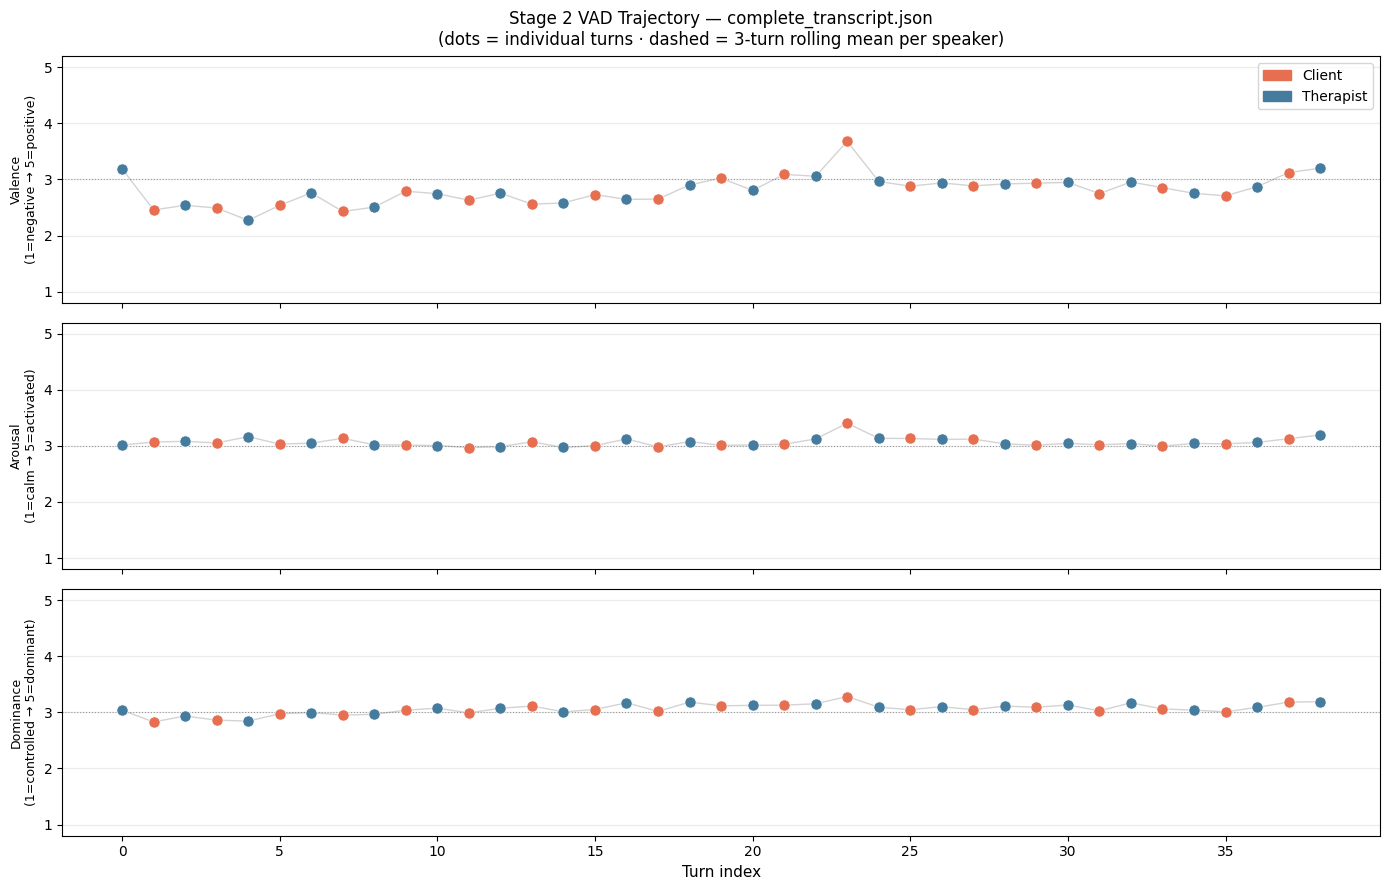

Saved complete_transcript_vad.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Load saved CSV (produced by the cell above)
df_plot = pd.read_csv(OUTPUT_DIR_PATH + "complete_transcript_context_output.csv").reset_index(drop=True)
df_plot["turn"] = df_plot.index

COLORS = {"client": "#E76F51", "therapist": "#457B9D"}
dims   = ["V", "A", "D"]
ylabels = [
    "Valence\n(1=negative → 5=positive)",
    "Arousal\n(1=calm → 5=activated)",
    "Dominance\n(1=controlled → 5=dominant)",
]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

for ax, dim, ylabel in zip(axes, dims, ylabels):
    # thin grey line connecting all turns
    ax.plot(df_plot["turn"], df_plot[dim],
            color="lightgray", linewidth=1.0, zorder=1)

    # scatter dots coloured by speaker
    for speaker, grp in df_plot.groupby("speaker"):
        ax.scatter(grp["turn"], grp[dim],
                   color=COLORS[speaker], label=speaker,
                   s=65, zorder=3, edgecolors="white", linewidth=0.5)

    # per-speaker 3-turn rolling mean (dashed)
    for speaker, grp in df_plot.groupby("speaker"):
        series = df_plot[dim].copy().astype(float)
        series[df_plot["speaker"] != speaker] = np.nan
        roll = series.rolling(3, min_periods=2, center=True).mean()
        ax.plot(df_plot["turn"], roll,
                color=COLORS[speaker], linewidth=2.0,
                linestyle="--", alpha=0.75, zorder=2)

    # neutral reference
    ax.axhline(3.0, color="black", linestyle=":", linewidth=0.8, alpha=0.35)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_ylim(0.8, 5.2)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.grid(axis="y", alpha=0.25)

axes[-1].set_xlabel("Turn index", fontsize=11)
axes[0].set_title(
    "Stage 2 VAD Trajectory — complete_transcript.json\n"
    "(dots = individual turns · dashed = 3-turn rolling mean per speaker)",
    fontsize=12, pad=8)

handles = [mpatches.Patch(color=c, label=s.capitalize())
           for s, c in COLORS.items()]
axes[0].legend(handles=handles, loc="upper right", fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR_PATH + "complete_transcript_context_vad.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved " + OUTPUT_DIR_PATH + "complete_transcript_context_vad.png")
